In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# Membaca dataset
df = pd.read_csv('online_shoppers_intention.csv')
print(f"=== STEP 1: DATASET BERHASIL DIMUAT ===")
print(f"Ukuran data awal: {df.shape[0]} baris dan {df.shape[1]} kolom")
df.head()

=== STEP 1: DATASET BERHASIL DIMUAT ===
Ukuran data awal: 12330 baris dan 18 kolom


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


=== STEP 2: GENERATING GRAFIK EDA ===


/tmp/ipykernel_1470/3552243286.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col_name, data=df, palette='Set2')


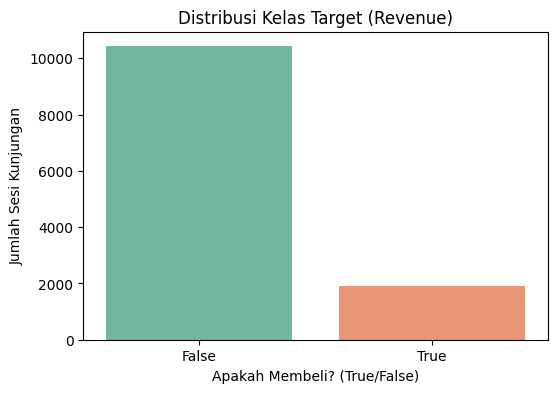

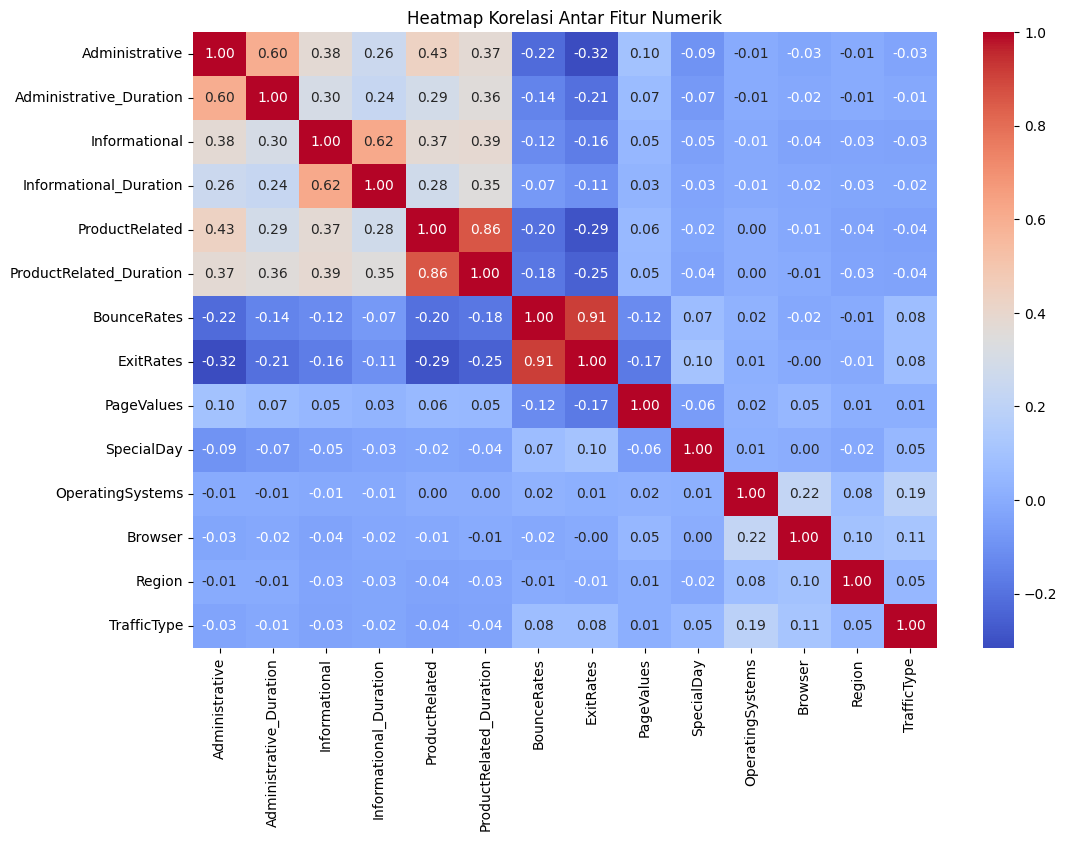

/tmp/ipykernel_1470/3552243286.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col_name, y='PageValues', data=df, palette='Set1')


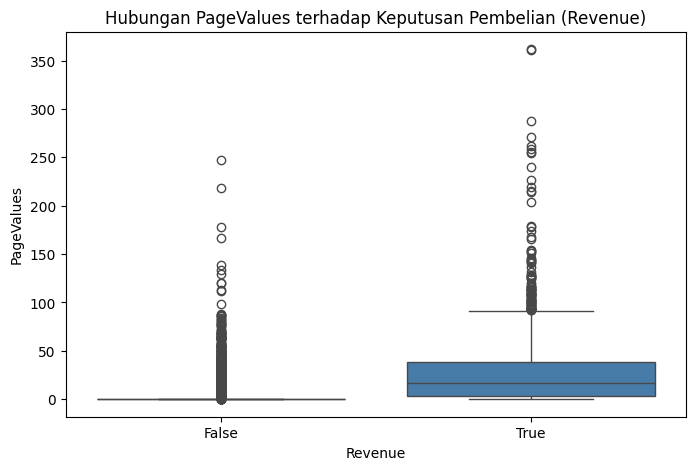

In [2]:
print("=== STEP 2: GENERATING GRAFIK EDA ===")

# Mencari nama kolom target secara aman (case-insensitive)
target_col_name = [c for c in df.columns if c.lower() == 'revenue'][0]

# Grafik 1: Distribusi Target (Melihat Imbalanced Class)
plt.figure(figsize=(6,4))
sns.countplot(x=target_col_name, data=df, palette='Set2')
plt.title('Distribusi Kelas Target (Revenue)')
plt.xlabel('Apakah Membeli? (True/False)')
plt.ylabel('Jumlah Sesi Kunjungan')
plt.show()

# Grafik 2: Heatmap Korelasi
plt.figure(figsize=(12,8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Antar Fitur Numerik')
plt.show()

# Grafik 3: Boxplot PageValues vs Revenue
plt.figure(figsize=(8,5))
sns.boxplot(x=target_col_name, y='PageValues', data=df, palette='Set1')
plt.title('Hubungan PageValues terhadap Keputusan Pembelian (Revenue)')
plt.show()

=== STEP 3: DATA PREPARATION + SMOTE (PENYEIMBANG DATA) ===


/tmp/ipykernel_1470/3792758093.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_res, palette='Set2')


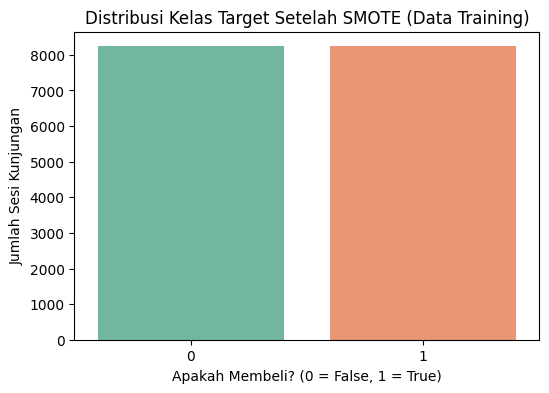


Selesai! Sekarang jumlah data training seimbang rata:
- Jumlah kelas False (0): 8238
- Jumlah kelas True (1) : 8238


In [6]:
print("=== STEP 3: DATA PREPARATION + SMOTE (PENYEIMBANG DATA) ===")

# 1. Hapus data duplikat jika ada
df = df.drop_duplicates()

# 2. Label Encoding otomatis untuk kolom teks/kategorikal
le = LabelEncoder()
for col in ['Month', 'VisitorType', 'Weekend', 'Revenue']:
    match = [c for c in df.columns if c.lower() == col.lower()]
    if match:
        df[match[0]] = le.fit_transform(df[match[0]].astype(str))

# 3. Memisahkan Fitur (X) dan Target (y)
X = df.drop(target_col_name, axis=1)
y = df[target_col_name]

# 4. Split data: 80% Training, 20% Testing (Lakukan split SEBELUM SMOTE agar evaluasi tetap valid)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Menerapkan SMOTE khusus pada DATA TRAINING agar grafik seimbang rata
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 6. Normalisasi data menggunakan StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# 7. Membuat Grafik Baru yang Sudah Seimbang Rata
plt.figure(figsize=(6,4))
sns.countplot(x=y_train_res, palette='Set2')
plt.title('Distribusi Kelas Target Setelah SMOTE (Data Training)')
plt.xlabel('Apakah Membeli? (0 = False, 1 = True)')
plt.ylabel('Jumlah Sesi Kunjungan')
plt.show()

print(f"\nSelesai! Sekarang jumlah data training seimbang rata:")
print(f"- Jumlah kelas False (0): {sum(y_train_res == 0)}")
print(f"- Jumlah kelas True (1) : {sum(y_train_res == 1)}")

In [7]:
print("=== STEP 4: MELATIH MODEL DENGAN DATA SEIMBANG ===")

# --- Model 1: K-Nearest Neighbors (KNN) ---
print("Sedang melatih model KNN...")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train_res)
y_pred_knn = knn.predict(X_test_scaled)

# --- Model 2: Support Vector Machine (SVM) ---
print("Sedang melatih model SVM...")
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train_scaled, y_train_res)
y_pred_svm = svm.predict(X_test_scaled)

print("\nSemua model selesai dilatih menggunakan data hasil SMOTE!")

=== STEP 4: MELATIH MODEL DENGAN DATA SEIMBANG ===
Sedang melatih model KNN...
Sedang melatih model SVM...

Semua model selesai dilatih menggunakan data hasil SMOTE!


In [8]:
print("=== STEP 5: EVALUASI KINERJA MODEL ===")

# Fungsi Cetak Evaluasi Rapi
def cetak_evaluasi(nama_model, y_asli, y_pred):
    print(f"\n[ EVALUASI MODEL {nama_model} ]")
    print("Confusion Matrix:")
    print(confusion_matrix(y_asli, y_pred))
    print("Metrik Evaluasi:")
    print(f"  - Accuracy  : {accuracy_score(y_asli, y_pred):.4f}")
    print(f"  - Precision : {precision_score(y_asli, y_pred):.4f}")
    print(f"  - Recall    : {recall_score(y_asli, y_pred):.4f}")
    print(f"  - F1-Score  : {f1_score(y_asli, y_pred):.4f}")

# Tampilkan hasil akhir kedua model
cetak_evaluasi("K-NEAREST NEIGHBORS (KNN)", y_test, y_pred_knn)
cetak_evaluasi("SUPPORT VECTOR MACHINE (SVM)", y_test, y_pred_svm)

=== STEP 5: EVALUASI KINERJA MODEL ===

[ EVALUASI MODEL K-NEAREST NEIGHBORS (KNN) ]
Confusion Matrix:
[[1680  379]
 [ 133  249]]
Metrik Evaluasi:
  - Accuracy  : 0.7902
  - Precision : 0.3965
  - Recall    : 0.6518
  - F1-Score  : 0.4931

[ EVALUASI MODEL SUPPORT VECTOR MACHINE (SVM) ]
Confusion Matrix:
[[1863  196]
 [ 127  255]]
Metrik Evaluasi:
  - Accuracy  : 0.8677
  - Precision : 0.5654
  - Recall    : 0.6675
  - F1-Score  : 0.6122
